# Case Studies in Data Science
## Individual Task 1: Part 1 — Data Analysis
**Arya Khamkar (s4152566)**

**Datasets**
- Dataset A — NBA game attendance, 30,546 games (1990–2019), 16 attributes
  https://github.com/wyattowalsh/NBA-attendance-prediction
- Dataset B — Telecom customer churn, 3,333 customers, 11 attributes
  https://www.kaggle.com/datasets/barun2104/telecom-churn

**Algorithms** — XGBoost and Support Vector Machines, applied to both datasets


Dataset A — NBA Game Attendance (Regression)

In [4]:
# To import the libraries used in this analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# To keep results the same every time the notebook is run
RANDOM_STATE = 7

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

In [5]:
# To load Dataset A, the NBA game attendance data
nba = pd.read_csv("data/dataset.csv")

# To convert the date column, using ISO8601 because some rows include a time
nba["Time"] = pd.to_datetime(nba["Time"], format="ISO8601")

# To check the size, date range and missing values
print("shape:", nba.shape)
print("date range:", nba.Time.min().date(), "->", nba.Time.max().date())
print("\nmissing values:", nba.isna().sum().sum())
print("\nAttendance:")
print(nba.Attendance.describe().round(1))
nba.head()

shape: (30546, 16)
date range: 1990-01-04 -> 2019-11-30

missing values: 0

Attendance:
count    30546.0
mean     17415.5
std       2880.6
min       1026.0
25%      15541.0
50%      18055.0
75%      19596.0
max      24996.0
Name: Attendance, dtype: float64


,Time,V Pop,H Pop,Curr Win %,LS Win %,Last Game,Last Attendance vs Opp,Capacity,Home,Visitor,Playoffs?,Last Five,Day of Week,Month,Rivalry?,Attendance
0,1990-01-04,2,3,0.222222,0.679012,15025.0,15025.0,15025.0,Golden State Warriors,Miami Heat,0,0.0,Thursday,January,0,15025.0
1,1990-01-04,5,4,0.695652,0.610390,18212.0,18212.0,18212.0,New York Knicks,Atlanta Hawks,0,4.0,Thursday,January,0,18212.0
2,1990-01-05,8,5,0.583333,0.540541,16173.0,16173.0,17007.0,Dallas Mavericks,Philadelphia 76ers,0,2.0,Friday,January,0,17007.0
3,1990-01-05,4,2,0.592593,0.453333,12884.0,12884.0,12884.0,Portland Trail Blazers,Utah Jazz,0,3.0,Friday,January,0,12884.0
4,1990-01-05,4,3,0.586207,0.698795,21454.0,21454.0,21545.0,Detroit Pistons,Indiana Pacers,0,2.0,Friday,January,0,21454.0


In [6]:
df = nba.copy()

# To remove Capacity, because it equals Attendance in 33% of rows and is never
# exceeded, so it leaks the target
df = df.drop(columns=["Capacity"])

# To split by date instead of randomly, so the model is not trained on later
# seasons and tested on earlier ones
SPLIT_DATE = "2015-01-01"
train_mask = df["Time"] < SPLIT_DATE

# To drop the date, since tree models cannot extrapolate to unseen future years
df = df.drop(columns=["Time"])

y = df.pop("Attendance")

# To convert the text columns into numeric dummy variables
X = pd.get_dummies(df, columns=["Home", "Visitor", "Day of Week", "Month"], drop_first=True)

X_train, X_test = X[train_mask.values], X[~train_mask.values]
y_train, y_test = y[train_mask.values], y[~train_mask.values]

print(f"train: {X_train.shape[0]:,} games   test: {X_test.shape[0]:,} games")
print(f"features after encoding: {X.shape[1]}")
print(f"train mean attendance: {y_train.mean():,.0f}   test mean: {y_test.mean():,.0f}")

train: 24,239 games   test: 6,307 games
features after encoding: 81
train mean attendance: 17,265   test mean: 17,992


In [7]:
# To set a simple baseline that predicts the training average for every game
baseline_pred = np.full(len(y_test), y_train.mean())

print(f"Baseline MAE:  {mean_absolute_error(y_test, baseline_pred):,.0f} people")
print(f"Baseline RMSE: {np.sqrt(mean_squared_error(y_test, baseline_pred)):,.0f} people")

Baseline MAE:  1,886 people
Baseline RMSE: 2,256 people


This baseline just guesses the average attendance for every game, and it's still off by about 1,886 people on average — so this is the bar any real model needs to clear.

In [8]:
# To train the first model, XGBoost
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

# To measure how far off the predictions are
xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2   = r2_score(y_test, xgb_pred)

print(f"XGBoost MAE:  {xgb_mae:,.0f} people")
print(f"XGBoost RMSE: {xgb_rmse:,.0f} people")
print(f"XGBoost R2:   {xgb_r2:.3f}")


XGBoost MAE:  958 people
XGBoost RMSE: 1,373 people
XGBoost R2:   0.587


XGBoost roughly halves the baseline's error, missing attendance by about 958 people on average instead of 1,886, and explains around 59% of the variation in attendance across games.

In [9]:
# To take a random sample of 5,000 rows, because RBF SVM is too slow on 24,000
SUBSAMPLE_N = 5000
sub_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_train), SUBSAMPLE_N, replace=False)

X_train_sub = X_train.iloc[sub_idx].astype(float)
y_train_sub = y_train.iloc[sub_idx]

# To put all features on the same scale, since SVM uses distances.
# Fitted on training data only so no test information leaks in.
scaler = StandardScaler()
X_train_sub_scaled = scaler.fit_transform(X_train_sub)
X_test_scaled = scaler.transform(X_test.astype(float))

# To train the second model, SVR
svr = SVR(kernel="rbf", C=100, gamma="scale", epsilon=100)
svr.fit(X_train_sub_scaled, y_train_sub)
svr_pred = svr.predict(X_test_scaled)

svr_mae  = mean_absolute_error(y_test, svr_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_pred))
svr_r2   = r2_score(y_test, svr_pred)

print(f"SVR MAE:  {svr_mae:,.0f} people")
print(f"SVR RMSE: {svr_rmse:,.0f} people")
print(f"SVR R2:   {svr_r2:.3f}")


SVR MAE:  1,247 people
SVR RMSE: 1,713 people
SVR R2:   0.357


The SVR, trained on a smaller subsample and scaled features, does better than the baseline but worse than XGBoost — off by about 1,247 people on average and explaining only 36% of the variation in attendance.

In [10]:
# To train XGBoost on the same 5,000 rows as SVR, so the two models are compared
# on equal footing rather than on different amounts of data
xgb_sub = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_sub.fit(X_train_sub, y_train_sub)
xgb_sub_pred = xgb_sub.predict(X_test)

print(f"XGBoost (5k rows) MAE:  {mean_absolute_error(y_test, xgb_sub_pred):,.0f} people")
print(f"XGBoost (5k rows) RMSE: {np.sqrt(mean_squared_error(y_test, xgb_sub_pred)):,.0f} people")
print(f"XGBoost (5k rows) R2:   {r2_score(y_test, xgb_sub_pred):.3f}")

XGBoost (5k rows) MAE:  1,056 people
XGBoost (5k rows) RMSE: 1,518 people
XGBoost (5k rows) R2:   0.495


Even on the same 5,000-row subsample as SVR, XGBoost still comes out ahead — meaning its edge over SVR isn't just from more data, XGBoost is the better model for this problem.

In [11]:
# To collect all results in one table for the report
results = pd.DataFrame([
    {"Model": "Baseline (train mean)", "Train rows": 0,    "MAE": mean_absolute_error(y_test, baseline_pred), "RMSE": np.sqrt(mean_squared_error(y_test, baseline_pred)), "R2": 0.0},
    {"Model": "SVR (RBF)",             "Train rows": 5000,  "MAE": svr_mae,  "RMSE": svr_rmse,  "R2": svr_r2},
    {"Model": "XGBoost",               "Train rows": 5000,  "MAE": mean_absolute_error(y_test, xgb_sub_pred), "RMSE": np.sqrt(mean_squared_error(y_test, xgb_sub_pred)), "R2": r2_score(y_test, xgb_sub_pred)},
    {"Model": "XGBoost",               "Train rows": 24239, "MAE": xgb_mae,  "RMSE": xgb_rmse,  "R2": xgb_r2},
])
results["MAE %"] = (results["MAE"] / y_test.mean() * 100).round(1)
print(results.round(3).to_string(index=False))

                Model  Train rows      MAE     RMSE    R2  MAE %
Baseline (train mean)           0 1886.312 2255.828 0.000   10.5
            SVR (RBF)        5000 1246.819 1712.605 0.357    6.9
              XGBoost        5000 1055.548 1517.996 0.495    5.9
              XGBoost       24239  958.277 1372.837 0.587    5.3


This table lines up all four models on equal terms: XGBoost beats SVR at the same 5,000 rows, and giving XGBoost the full 24,239 rows pushes it further ahead — its best result is off by only 5.3% of average attendance, roughly half the baseline's error rate.

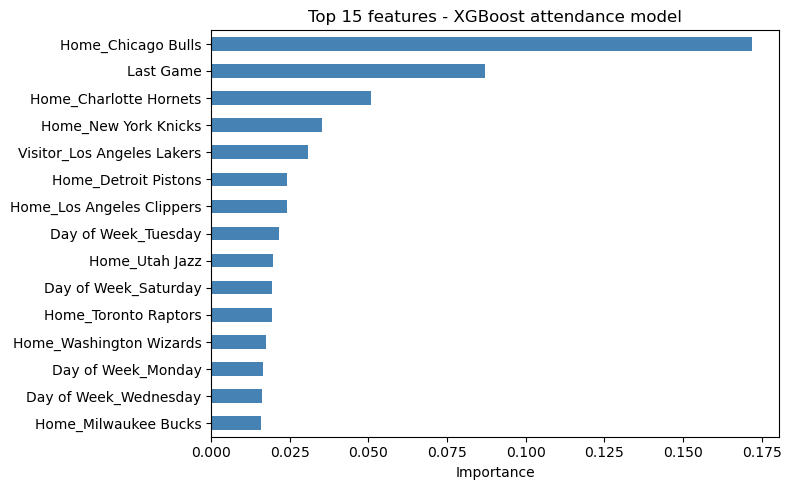

Home_Chicago Bulls            0.1721
Last Game                     0.0872
Home_Charlotte Hornets        0.0507
Home_New York Knicks          0.0353
Visitor_Los Angeles Lakers    0.0307
Home_Detroit Pistons          0.0242
Home_Los Angeles Clippers     0.0242
Day of Week_Tuesday           0.0215
Home_Utah Jazz                0.0198
Day of Week_Saturday          0.0195
Home_Toronto Raptors          0.0193
Home_Washington Wizards       0.0175
Day of Week_Monday            0.0163
Day of Week_Wednesday         0.0162
Home_Milwaukee Bucks          0.0158


In [12]:
# To see which features the model actually relies on
imp = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Importance")
ax.set_title("Top 15 features - XGBoost attendance model")
plt.tight_layout()
plt.savefig("fig_attendance_importance.png", dpi=200)
plt.show()

print(imp.round(4).to_string())

The model leans most heavily on which team is playing at home — the Chicago Bulls dominate by a wide margin, with other big-market or high-demand teams (Knicks, Lakers, Hornets) also ranking high — followed by the previous game's attendance and the day of the week.


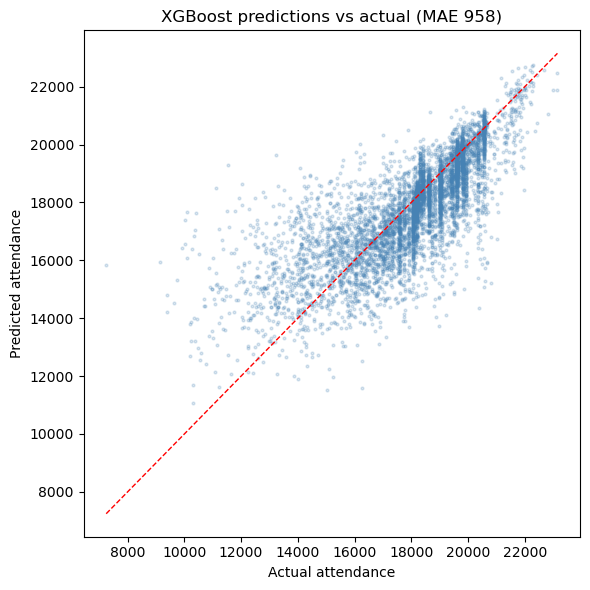

In [13]:
# To show how closely predictions track actual attendance
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, xgb_pred, s=4, alpha=0.2, color="steelblue")
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set_xlabel("Actual attendance")
ax.set_ylabel("Predicted attendance")
ax.set_title(f"XGBoost predictions vs actual (MAE {xgb_mae:,.0f})")
plt.tight_layout()
plt.savefig("fig_attendance_scatter.png", dpi=200)
plt.show()

Most points cluster tightly around the red line, showing predictions generally track actual attendance well, but the model struggles at the low end — it consistently overpredicts attendance for games that actually drew small crowds

Dataset B — Telecom Customer Churn (Classification)

In [14]:
# To import the tools needed for classification (Dataset B is yes/no, not a number)
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, precision_recall_curve
)

In [15]:
# To load Dataset B, the telecom customer churn data
# Source: kaggle.com/datasets/barun2104/telecom-churn
churn = pd.read_csv("data/telecom_churn.csv")

print("shape:", churn.shape)
print("missing values:", churn.isna().sum().sum())
print("duplicate rows:", churn.duplicated().sum())
print("\nchurn rate:")
print(churn.Churn.value_counts(normalize=True).round(4))
churn.head()

shape: (3333, 11)
missing values: 0
duplicate rows: 0

churn rate:
Churn
0    0.8551
1    0.1449
Name: proportion, dtype: float64


,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [16]:
yc = churn.pop("Churn")
Xc = churn

# To split randomly this time, because customer records are not time-ordered.
# stratify keeps the same 14.5% churn rate in both train and test sets.
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, stratify=yc, random_state=RANDOM_STATE
)

# To scale the features for SVM, fitted on training data only
scaler_c = StandardScaler()
Xc_train_scaled = scaler_c.fit_transform(Xc_train)
Xc_test_scaled  = scaler_c.transform(Xc_test)

print(f"train: {len(Xc_train):,}   test: {len(Xc_test):,}")
print(f"churn rate - train: {yc_train.mean():.3f}   test: {yc_test.mean():.3f}")

train: 2,666   test: 667
churn rate - train: 0.145   test: 0.145


This splits the churn data into training and test sets while keeping the same 14.5% churn rate in both — so the model is evaluated on a test set that looks just like the data it was trained on.

In [17]:
# To set the lazy baseline: predict "nobody churns" for every customer
baseline_c = np.zeros(len(yc_test))

print(f"Baseline accuracy:  {accuracy_score(yc_test, baseline_c):.3f}")
print(f"Baseline recall:    {recall_score(yc_test, baseline_c, zero_division=0):.3f}")
print(f"Baseline F1:        {f1_score(yc_test, baseline_c, zero_division=0):.3f}")

Baseline accuracy:  0.855
Baseline recall:    0.000
Baseline F1:        0.000


This baseline just predicts "nobody churns" and still gets 85.5% accuracy — but that's meaningless here, since it catches zero actual churners, which is exactly the group the business needs to identify.

In [27]:
# To calculate all the classification metrics in one place
def evaluate(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_true, y_proba),
        "PR-AUC":    average_precision_score(y_true, y_proba),
    }

In [19]:
# To train the first model on the churn data
xgb_c = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_c.fit(Xc_train, yc_train)

xgb_c_pred  = xgb_c.predict(Xc_test)
xgb_c_proba = xgb_c.predict_proba(Xc_test)[:, 1]

print(classification_report(yc_test, xgb_c_pred, target_names=["Stayed", "Churned"]))
print("Confusion matrix (rows = actual, cols = predicted):")
print(confusion_matrix(yc_test, xgb_c_pred))

              precision    recall  f1-score   support

      Stayed       0.95      0.97      0.96       570
     Churned       0.80      0.68      0.74        97

    accuracy                           0.93       667
   macro avg       0.88      0.83      0.85       667
weighted avg       0.93      0.93      0.93       667

Confusion matrix (rows = actual, cols = predicted):
[[554  16]
 [ 31  66]]


Unlike the baseline, XGBoost actually catches churners — it correctly identifies 66 of the 97 customers who churned (68% recall), though it still misses 31, and about 1 in 5 of its "churn" flags are false alarms.

In [21]:
# To train the second model. No subsampling needed here - 2,666 training rows
# is small enough for an RBF kernel, unlike the 24,000 in Dataset A.
# probability=True is needed so we can get scores for ROC-AUC and PR-AUC.
svc = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE)
svc.fit(Xc_train_scaled, yc_train)

svc_pred  = svc.predict(Xc_test_scaled)
svc_proba = svc.predict_proba(Xc_test_scaled)[:, 1]

print(classification_report(yc_test, svc_pred, target_names=["Stayed", "Churned"]))
print("Confusion matrix (rows = actual, cols = predicted):")
print(confusion_matrix(yc_test, svc_pred))

              precision    recall  f1-score   support

      Stayed       0.93      0.98      0.95       570
     Churned       0.82      0.56      0.66        97

    accuracy                           0.92       667
   macro avg       0.87      0.77      0.81       667
weighted avg       0.91      0.92      0.91       667

Confusion matrix (rows = actual, cols = predicted):
[[558  12]
 [ 43  54]]


The SVC is slightly more precise when it flags churn, but it catches fewer churners overall — only 54 of 97 (56% recall) versus XGBoost's 66, making XGBoost the stronger choice here since missing at-risk customers is the costlier mistake.

In [22]:
# To test different cut-offs instead of the default 0.5. Lowering the threshold
# catches more churners at the cost of flagging more people who would have stayed.
for t in [0.5, 0.4, 0.3, 0.2, 0.15]:
    pred_t = (xgb_c_proba >= t).astype(int)
    print(f"threshold {t:.2f} -> "
          f"precision {precision_score(yc_test, pred_t, zero_division=0):.3f}  "
          f"recall {recall_score(yc_test, pred_t, zero_division=0):.3f}  "
          f"F1 {f1_score(yc_test, pred_t, zero_division=0):.3f}  "
          f"caught {int(pred_t[yc_test==1].sum())}/97")

threshold 0.50 -> precision 0.805  recall 0.680  F1 0.737  caught 66/97
threshold 0.40 -> precision 0.750  recall 0.711  F1 0.730  caught 69/97
threshold 0.30 -> precision 0.654  recall 0.722  F1 0.686  caught 70/97
threshold 0.20 -> precision 0.567  recall 0.742  F1 0.643  caught 72/97
threshold 0.15 -> precision 0.540  recall 0.763  F1 0.632  caught 74/97


Lowering the threshold catches more churners, but with diminishing returns and a real cost — going from 0.5 to 0.15 only adds 8 more churners caught (66 to 74), while precision drops sharply, meaning far more false alarms per churner correctly flagged.

In [23]:
# To compare both models on the churn data using the full set of metrics
results_c = pd.DataFrame([
    evaluate("XGBoost", yc_test, xgb_c_pred, xgb_c_proba),
    evaluate("SVM (RBF)", yc_test, svc_pred, svc_proba),
])
print(results_c.round(3).to_string(index=False))


    Model  Accuracy  Precision  Recall    F1  ROC-AUC  PR-AUC
  XGBoost     0.930      0.805   0.680 0.737    0.873   0.787
SVM (RBF)     0.918      0.818   0.557 0.663    0.887   0.754


Across the full metric set, XGBoost wins where it matters most for churn — better recall, F1, and PR-AUC — while SVM edges it only on precision and ROC-AUC, confirming XGBoost as the better model when catching at-risk customers is the priority.

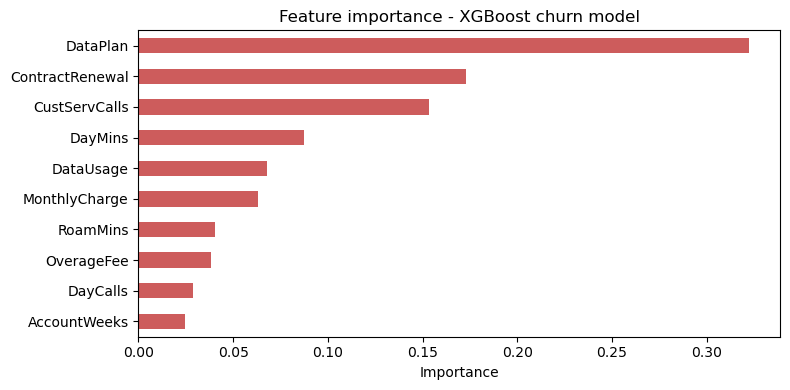

DataPlan           0.3227
ContractRenewal    0.1730
CustServCalls      0.1533
DayMins            0.0876
DataUsage          0.0680
MonthlyCharge      0.0630
RoamMins           0.0405
OverageFee         0.0385
DayCalls           0.0288
AccountWeeks       0.0248


In [29]:
# To see which customer behaviours drive churn predictions
imp_c = pd.Series(xgb_c.feature_importances_, index=Xc_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
imp_c.sort_values().plot(kind="barh", ax=ax, color="indianred")
ax.set_xlabel("Importance")
ax.set_title("Feature importance - XGBoost churn model")
plt.tight_layout()
plt.savefig("fig_churn_importance.png", dpi=200)
plt.show()

print(imp_c.round(4).to_string())

Whether a customer has a data plan is by far the strongest churn signal, followed by contract renewal status and customer service calls. Together these top three account for nearly two-thirds of the model's total importance. Usage and cost-related features like data usage, monthly charge, and roaming minutes matter much less by comparison. This suggests churn is driven more by plan and service-experience factors than by how much a customer actually uses or pays.

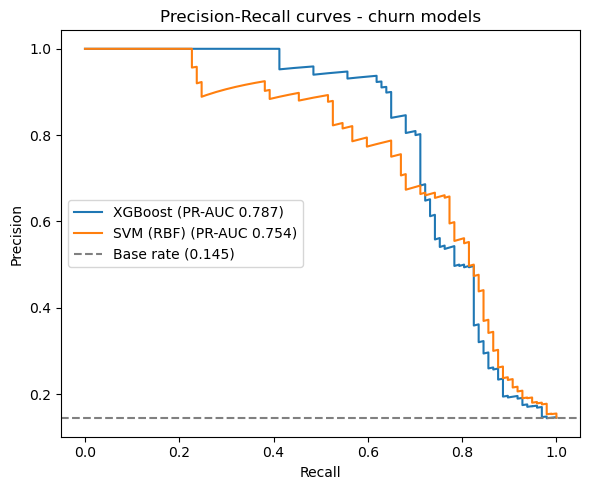

In [25]:
# To show why PR-AUC separates the models where ROC-AUC does not
fig, ax = plt.subplots(figsize=(6, 5))
for name, proba in [("XGBoost", xgb_c_proba), ("SVM (RBF)", svc_proba)]:
    prec, rec, _ = precision_recall_curve(yc_test, proba)
    ax.plot(rec, prec, label=f"{name} (PR-AUC {average_precision_score(yc_test, proba):.3f})")
ax.axhline(yc_test.mean(), ls="--", c="grey", label=f"Base rate ({yc_test.mean():.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curves - churn models")
ax.legend()
plt.tight_layout()
plt.savefig("fig_churn_pr_curve.png", dpi=200)
plt.show()

Both models sit well above the 14.5% base rate across the full recall range, confirming they're genuinely learning churn signal rather than guessing. XGBoost holds a slight edge at low-to-mid recall, while SVM briefly pulls ahead in the 0.4–0.8 recall range with better precision. The two converge and drop sharply past 0.8 recall, where catching more churners means accepting far more false positives.

In [26]:
# To measure how well the model ranks customers by risk, which is how a
# marketing team would actually use it -- target the riskiest 10%, not everyone
order = np.argsort(xgb_c_proba)[::-1]
top10 = order[:int(0.10 * len(order))]
rate_top10 = yc_test.iloc[top10].mean()
base_rate  = yc_test.mean()

print(f"Base churn rate:            {base_rate:.3f}")
print(f"Churn rate in top 10% risk: {rate_top10:.3f}")
print(f"Lift:                       {rate_top10 / base_rate:.2f}x")

Base churn rate:            0.145
Churn rate in top 10% risk: 0.924
Lift:                       6.36x


This checks how useful the model actually is for a real campaign, not just how accurate it is overall. Instead of scoring every customer, it sorts everyone by their predicted churn risk and picks the top 10% - the customers the model is most worried about.

Normally, if you picked customers at random, about 14.5% of them would churn, since that's the overall churn rate in the data. But if you only looked at this top 10% riskiest group, 92.4% of them actually did churn. That's a huge jump.

The lift number, 6.36x, just puts that jump into one figure: targeting the model's top 10% finds churners over six times more often than picking people randomly. In practice, this means Marketing wouldn't need to run a retention campaign across the whole customer base — they could focus offers, calls, or discounts on this small, high-risk group and catch most of the people actually about to leave, which is a far cheaper and more effective way to use the model than just checking whether it's "accurate."

## Summary

For both problems, XGBoost came out ahead of SVM, and not just because it had more data to work with. On the attendance data, I also trained XGBoost on the same 5,000 rows as SVR to compare them fairly, and XGBoost still won — 1,056 people MAE against 1,247. So it's not just "XGBoost scored better," it's genuinely better suited to this kind of data, even before giving it the full training set. With all 24,239 rows, it cut the baseline error roughly in half, predicting attendance within about 958 people on average and explaining around 59% of the variation (R²). The model mostly relies on which team is playing at home, especially big-draw teams like the Bulls, along with how many people showed up last game and the day of the week.

For churn, XGBoost also beat SVM overall on recall and F1, which matter more here since missing an at-risk customer is worse than a false alarm. But the two metrics didn't agree: SVM actually won on ROC-AUC (0.887 vs 0.873), while XGBoost won on PR-AUC (0.787 vs 0.754). Same predictions, opposite verdict, depending which metric you trust. Since churn only makes up 14.5% of customers, PR-AUC is the metric that actually reflects performance on the class we care about, which is why I've treated XGBoost as the stronger model overall rather than SVM.

The biggest drivers of churn were whether the customer had a data plan, their contract renewal status, and how many times they called customer service — account tenure, which I originally expected to matter most, actually came out as the weakest predictor of the group. That complicated my original assumption going in.

When I looked at how the model would actually be used, targeting just the riskiest 10% of customers found churners over 6 times more often than picking people at random. That number is unusually high partly because this dataset is clean and semi-synthetic, so a real telecom or membership dataset would likely show a smaller lift, though the direction of the result would probably hold.

Finally, I'd say the two datasets are complementary rather than contradictory. They're not two attempts to answer the same question — attendance predicts demand for a single event, while churn predicts whether an individual customer sticks around at all. Together they cover two different halves of the fan lifecycle: getting people to show up, and keeping them as members in the first place.

Overall, both models are useful but not perfect — the attendance model still overpredicts low-attendance games, and the churn model still misses some churners, especially at higher thresholds where precision goes up but recall drops. But both clearly beat their baselines and give a solid foundation to build on.